# [Deep Agents - 메트릭 추적 미들웨어](https://docs.langchain.com/oss/python/deepagents/middleware)

Deep Agents의 미들웨어 아키텍처를 활용하여 토큰 사용량과 실행 시간을 추적하는 시스템을 구축합니다.
이를 통해 에이전트의 성능을 모니터링하고 비용을 최적화할 수 있습니다.


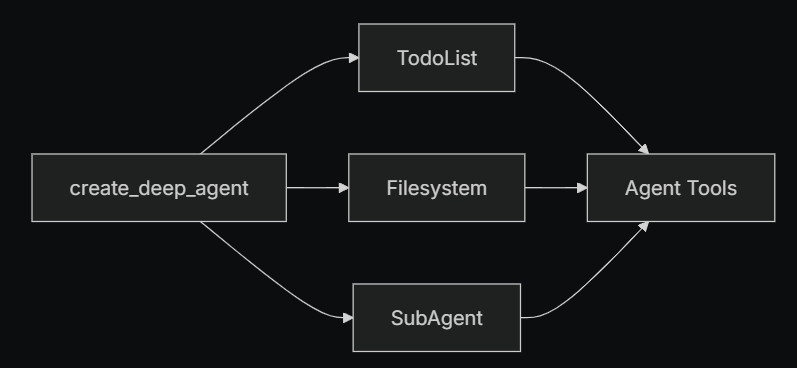

## Middleware란?

애플리케이션의 핵심 로직을 수정하지 않고도 공통 기능이나 동작 방식을 중간 계층에서 주입하는 구조를 의미한다.

웹 서버 예시:
- 인증 미들웨어
- 로깅 미들웨어
- 트랜잭션 관리 미들웨어

## DeepAgents에서의 Middleware

DeepAgents에서 Middleware는 에이전트의 사고 방식과 행동 패턴을 확장하는 구성 요소다.
- 에이전트의 코어 로직은 그대로 유지
- 추가적인 도구(tools), 규칙, 시스템 프롬프트를 주입
- 에이전트가 “어떻게 행동해야 하는지”를 구조적으로 정의

> 즉, 에이전트를 직접 고치지 않고도 새로운 능력을 부여하는 방법이다.

# 메트릭 추적 미들웨어 예제 

## Setup

### 환경 변수 설정
- [OpenAI API Key](https://platform.openai.com/api-keys)
- [Tavily API Key](https://tavily.com/) - 웹 검색용
- [LangSmith API Key](https://smith.langchain.com/)

In [1]:
from dotenv import load_dotenv

# 환경 변수 로드
load_dotenv()

True

### LLM 정의 

In [2]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    model="gpt-5-nano",
    reasoning_effort="high",        # 논리성 강화
)


## 1. Deep Agent 기본 이해

먼저 기본 Deep Agent를 생성하고 메트릭 추적의 필요성을 이해합니다.

### 도구 정의 

In [ ]:
from langchain_tavily import TavilySearch

# Tavily 검색 도구 설정
tavily_search = TavilySearch(
    max_results=5,
    search_depth="advanced",
    include_answer=True,
    include_raw_content=False,
)

In [ ]:
from langchain.tools import tool

# 실제 작동하는 도구 정의
@tool
def search_web(query: str) -> str:
    """Tavily를 사용하여 웹을 검색합니다.
    
    Args:
        query: 검색 쿼리
        
    Returns:
        검색 결과 요약
    """
    try:
        results = tavily_search.invoke(query)
        if not results:
            return f"'{query}'에 대한 검색 결과를 찾을 수 없습니다."
        
        # 결과 포맷팅
        formatted_results = []
        for idx, result in enumerate(results[:5], 1):
            title = result.get('title', '제목 없음')
            url = result.get('url', '')
            content = result.get('content', '')
            formatted_results.append(f"{idx}. {title}\n   URL: {url}\n   내용: {content[:200]}...\n")
        
        return f"'{query}' 검색 결과:\n\n" + "\n".join(formatted_results)
    except Exception as e:
        return f"검색 중 오류 발생: {str(e)}"


In [ ]:
import os

@tool
def write_document(content: str, filename: str) -> str:
    """문서를 파일로 작성합니다.
    
    Args:
        content: 문서 내용
        filename: 파일명
        
    Returns:
        작성 결과 메시지
    """
    try:
        # 파일 저장 경로 설정
        filepath = os.path.join(os.getcwd(), filename)
        
        with open(filepath, 'w', encoding='utf-8') as f:
            f.write(content)
        
        return f"문서 '{filename}' 작성 완료 ({len(content)}자)\n저장 위치: {filepath}"
    except Exception as e:
        return f"문서 작성 중 오류 발생: {str(e)}"


실제 작동하는 도구 정의 완료 (Tavily 검색 포함)


### 기본 Deep Agent 생성

In [4]:
from deepagents import create_deep_agent

# 기본 Deep Agent 생성
basic_agent = create_deep_agent(
    model=llm,
    tools=[search_web, write_document]
)

print("기본 Deep Agent 생성 완료")
print("\n메트릭 추적의 필요성:")
print("  - 토큰 사용량 모니터링 → 비용 관리")
print("  - 실행 시간 측정 → 성능 최적화")
print("  - 도구 호출 통계 → 효율성 분석")
print("  - 에러율 추적 → 안정성 향상")

기본 Deep Agent 생성 완료

메트릭 추적의 필요성:
  - 토큰 사용량 모니터링 → 비용 관리
  - 실행 시간 측정 → 성능 최적화
  - 도구 호출 통계 → 효율성 분석
  - 에러율 추적 → 안정성 향상


## 2. 메트릭 추적 미들웨어 구현

토큰 사용량, 실행 시간, 도구 호출 등 다양한 메트릭을 추적하는 커스텀 미들웨어를 만듭니다.

In [6]:
# 필요한 타입과 클래스 import
from langchain.agents.middleware.types import AgentMiddleware
from langchain_core.callbacks.base import BaseCallbackHandler
from langchain_core.outputs import LLMResult
from typing import Dict, List, Any, Optional
from datetime import datetime
import asyncio


class MetricsTrackingMiddleware(AgentMiddleware):
    """Deep Agent용 메트릭 추적 미들웨어
    
    토큰 사용량, 실행 시간, 도구 호출 통계 등을 추적하는 커스텀 미들웨어입니다.
    AgentMiddleware를 상속받아 Deep Agent 시스템과 통합됩니다.
    """
    
    def __init__(self, handlers: Optional[List[BaseCallbackHandler]] = None):
        """미들웨어 초기화
        
        Args:
            handlers: 메트릭 이벤트를 받을 핸들러 목록 (선택사항)
        """
        super().__init__()
        self.handlers = handlers or []
        
        # 메트릭 데이터를 추적하기 위한 데이터 구조
        self.metrics = {
            'total_tokens': 0,              # 총 사용 토큰 수
            'prompt_tokens': 0,             # 프롬프트 토큰 수
            'completion_tokens': 0,         # 완료 토큰 수
            'llm_calls': 0,                 # LLM 호출 횟수
            'tool_calls': 0,                # 도구 호출 횟수
            'errors': 0,                    # 에러 발생 횟수
            'start_time': datetime.now(),   # 시작 시간
            'tool_usage': {},               # 도구별 사용 통계
            'execution_times': [],          # 각 단계별 실행 시간
        }
        
        # 현재 실행 중인 작업 추적
        self.current_execution = {
            'start_time': None,
            'step_name': None,
        }
    
    def add_handler(self, handler: BaseCallbackHandler):
        """새로운 핸들러를 추가
        
        Args:
            handler: 추가할 콜백 핸들러
        """
        self.handlers.append(handler)
    
    async def on_llm_start(self, prompts: List[str], **kwargs):
        """LLM 호출이 시작될 때 호출되는 메서드
        
        Args:
            prompts: LLM에 전달되는 프롬프트 목록
        """
        self.metrics['llm_calls'] += 1
        self.current_execution['start_time'] = datetime.now()
        self.current_execution['step_name'] = 'LLM 호출'
        
        await self._notify_handlers('llm_start', {
            'call_number': self.metrics['llm_calls'],
            'prompt_length': sum(len(p) for p in prompts),
        })
    
    async def on_llm_end(self, response: LLMResult, **kwargs):
        """LLM 호출이 완료될 때 호출되는 메서드
        
        Args:
            response: LLM 응답 결과
        """
        # 실행 시간 계산
        if self.current_execution['start_time']:
            elapsed = (datetime.now() - self.current_execution['start_time']).total_seconds()
            self.metrics['execution_times'].append({
                'step': self.current_execution['step_name'],
                'duration': elapsed,
                'timestamp': datetime.now().isoformat()
            })
        
        # 토큰 사용량 추출 (llm_output에서)
        if hasattr(response, 'llm_output') and response.llm_output:
            token_usage = response.llm_output.get('token_usage', {})
            
            prompt_tokens = token_usage.get('prompt_tokens', 0)
            completion_tokens = token_usage.get('completion_tokens', 0)
            total_tokens = token_usage.get('total_tokens', 0)
            
            self.metrics['prompt_tokens'] += prompt_tokens
            self.metrics['completion_tokens'] += completion_tokens
            self.metrics['total_tokens'] += total_tokens
            
            # 비용 계산 (gpt-4o-mini 기준: $0.150/1M input, $0.600/1M output)
            input_cost = (prompt_tokens / 1_000_000) * 0.150
            output_cost = (completion_tokens / 1_000_000) * 0.600
            total_cost = input_cost + output_cost
            
            await self._notify_handlers('llm_end', {
                'prompt_tokens': prompt_tokens,
                'completion_tokens': completion_tokens,
                'total_tokens': total_tokens,
                'cost': total_cost,
                'elapsed_time': elapsed if self.current_execution['start_time'] else 0,
            })
    
    async def on_tool_start(self, tool_name: str, tool_input: str, **kwargs):
        """도구 호출이 시작될 때 호출되는 메서드
        
        Args:
            tool_name: 호출되는 도구의 이름
            tool_input: 도구에 전달되는 입력
        """
        self.metrics['tool_calls'] += 1
        self.current_execution['start_time'] = datetime.now()
        self.current_execution['step_name'] = f'도구: {tool_name}'
        
        # 도구별 사용 통계 업데이트
        if tool_name not in self.metrics['tool_usage']:
            self.metrics['tool_usage'][tool_name] = {
                'count': 0,
                'total_time': 0,
            }
        self.metrics['tool_usage'][tool_name]['count'] += 1
        
        await self._notify_handlers('tool_start', {
            'tool_name': tool_name,
            'tool_input': str(tool_input)[:100],  # 처음 100자만
        })
    
    async def on_tool_end(self, tool_name: str, output: str, **kwargs):
        """도구 호출이 완료될 때 호출되는 메서드
        
        Args:
            tool_name: 완료된 도구의 이름
            output: 도구의 출력 결과
        """
        # 실행 시간 계산
        elapsed = 0
        if self.current_execution['start_time']:
            elapsed = (datetime.now() - self.current_execution['start_time']).total_seconds()
            self.metrics['execution_times'].append({
                'step': self.current_execution['step_name'],
                'duration': elapsed,
                'timestamp': datetime.now().isoformat()
            })
            
            # 도구별 총 실행 시간 업데이트
            if tool_name in self.metrics['tool_usage']:
                self.metrics['tool_usage'][tool_name]['total_time'] += elapsed
        
        await self._notify_handlers('tool_end', {
            'tool_name': tool_name,
            'elapsed_time': elapsed,
            'output_length': len(str(output)),
        })
    
    async def on_error(self, error: Exception, **kwargs):
        """에러 발생 시 호출되는 메서드
        
        Args:
            error: 발생한 예외
        """
        self.metrics['errors'] += 1
        
        await self._notify_handlers('error', {
            'error_type': type(error).__name__,
            'error_message': str(error),
            'total_errors': self.metrics['errors'],
        })
    
    async def _notify_handlers(self, event_type: str, data: Dict[str, Any]):
        """등록된 모든 핸들러에게 이벤트를 전달하는 내부 메서드
        
        Args:
            event_type: 이벤트 타입
            data: 이벤트 데이터
        """
        event = {'type': event_type, **data}
        
        for handler in self.handlers:
            if hasattr(handler, 'on_metrics_event'):
                if asyncio.iscoroutinefunction(handler.on_metrics_event):
                    await handler.on_metrics_event(event)
                else:
                    handler.on_metrics_event(event)
    
    def get_metrics_summary(self) -> Dict[str, Any]:
        """현재 메트릭의 요약 정보를 반환
        
        Returns:
            Dict: 토큰 사용량, 실행 시간, 도구 사용 통계 등
        """
        elapsed = (datetime.now() - self.metrics['start_time']).total_seconds()
        
        # 총 비용 계산 (gpt-4o-mini 기준)
        input_cost = (self.metrics['prompt_tokens'] / 1_000_000) * 0.150
        output_cost = (self.metrics['completion_tokens'] / 1_000_000) * 0.600
        total_cost = input_cost + output_cost
        
        # 평균 실행 시간
        avg_execution_time = (
            sum(e['duration'] for e in self.metrics['execution_times']) / 
            len(self.metrics['execution_times'])
        ) if self.metrics['execution_times'] else 0
        
        return {
            'elapsed_time': elapsed,
            'total_tokens': self.metrics['total_tokens'],
            'prompt_tokens': self.metrics['prompt_tokens'],
            'completion_tokens': self.metrics['completion_tokens'],
            'estimated_cost': total_cost,
            'llm_calls': self.metrics['llm_calls'],
            'tool_calls': self.metrics['tool_calls'],
            'errors': self.metrics['errors'],
            'tool_usage': self.metrics['tool_usage'],
            'avg_execution_time': avg_execution_time,
            'execution_times': self.metrics['execution_times'],
        }


print("MetricsTrackingMiddleware 정의 완료")

MetricsTrackingMiddleware 정의 완료


## 3. 메트릭 대시보드 핸들러

미들웨어에서 발생한 메트릭 이벤트를 받아 대시보드에 표시하는 핸들러입니다.

In [ ]:
class MetricsDashboardHandler(BaseCallbackHandler):
    """메트릭을 대시보드 형식으로 표시하는 핸들러
    
    MetricsTrackingMiddleware로부터 이벤트를 받아 사용자가 보기 쉬운 형태로 출력합니다.
    """
    
    def __init__(self, verbose: bool = True, show_details: bool = True):
        """핸들러 초기화
        
        Args:
            verbose: True이면 이벤트를 콘솔에 출력
            show_details: True이면 상세 정보 표시
        """
        self.verbose = verbose
        self.show_details = show_details
        self.event_history = []
        
        # 누적 통계
        self.cumulative = {
            'total_tokens': 0,
            'total_cost': 0.0,
            'llm_calls': 0,
            'tool_calls': 0,
        }
    
    def on_metrics_event(self, event: Dict[str, Any]):
        """메트릭 이벤트를 처리하는 메인 메서드
        
        Args:
            event: 이벤트 정보가 담긴 딕셔너리
        """
        self.event_history.append(event)
        
        if not self.verbose:
            return
        
        event_type = event.get('type')
        
        if event_type == 'llm_start':
            self._display_llm_start(event)
        elif event_type == 'llm_end':
            self._display_llm_end(event)
        elif event_type == 'tool_start':
            self._display_tool_start(event)
        elif event_type == 'tool_end':
            self._display_tool_end(event)
        elif event_type == 'error':
            self._display_error(event)
    
    def _display_llm_start(self, event: Dict[str, Any]):
        """LLM 시작 이벤트를 화면에 표시"""
        self.cumulative['llm_calls'] += 1
        if self.show_details:
            print(f"\nLLM 호출 #{event['call_number']}")
            print(f"   프롬프트 길이: {event['prompt_length']}자")
    
    def _display_llm_end(self, event: Dict[str, Any]):
        """LLM 완료 이벤트를 화면에 표시"""
        self.cumulative['total_tokens'] += event['total_tokens']
        self.cumulative['total_cost'] += event['cost']
        
        print(f"\nLLM 응답 완료")
        print(f"   토큰: {event['prompt_tokens']} (입력) + {event['completion_tokens']} (출력) = {event['total_tokens']} (총)")
        print(f"   비용: ${event['cost']:.6f}")
        print(f"   시간: {event['elapsed_time']:.2f}초")
        
        if self.show_details:
            print(f"\n누적 통계:")
            print(f"   총 토큰: {self.cumulative['total_tokens']:,}")
            print(f"   총 비용: ${self.cumulative['total_cost']:.6f}")
            print(f"   LLM 호출: {self.cumulative['llm_calls']}회")
    
    def _display_tool_start(self, event: Dict[str, Any]):
        """도구 시작 이벤트를 화면에 표시"""
        self.cumulative['tool_calls'] += 1
        if self.show_details:
            print(f"\n도구 호출: {event['tool_name']}")
            print(f"   입력: {event['tool_input']}")
    
    def _display_tool_end(self, event: Dict[str, Any]):
        """도구 완료 이벤트를 화면에 표시"""
        print(f"\n도구 완료: {event['tool_name']}")
        print(f"   실행 시간: {event['elapsed_time']:.2f}초")
        print(f"   출력 크기: {event['output_length']}자")
    
    def _display_error(self, event: Dict[str, Any]):
        """에러 이벤트를 화면에 표시"""
        print(f"\n에러 발생: {event['error_type']}")
        print(f"   메시지: {event['error_message']}")
        print(f"   총 에러 수: {event['total_errors']}")
    
    def display_final_summary(self, metrics_summary: Dict[str, Any]):
        """최종 메트릭 요약을 대시보드 형식으로 표시
        
        Args:
            metrics_summary: get_metrics_summary()에서 반환된 메트릭 데이터
        """
        print(f"\n{'='*70}")
        print(f"최종 메트릭 대시보드")
        print(f"{'='*70}")
        
        # 시간 정보
        print(f"\n실행 시간:")
        print(f"   총 경과 시간: {metrics_summary['elapsed_time']:.2f}초")
        print(f"   평균 단계 시간: {metrics_summary['avg_execution_time']:.2f}초")
        
        # 토큰 사용량
        print(f"\n토큰 사용량:")
        print(f"   프롬프트 토큰: {metrics_summary['prompt_tokens']:,}")
        print(f"   완료 토큰: {metrics_summary['completion_tokens']:,}")
        print(f"   총 토큰: {metrics_summary['total_tokens']:,}")
        
        # 비용
        print(f"\n예상 비용:")
        print(f"   총 비용: ${metrics_summary['estimated_cost']:.6f}")
        if metrics_summary['llm_calls'] > 0:
            avg_cost = metrics_summary['estimated_cost'] / metrics_summary['llm_calls']
            print(f"   호출당 평균: ${avg_cost:.6f}")
        
        # 호출 통계
        print(f"\n호출 통계:")
        print(f"   LLM 호출: {metrics_summary['llm_calls']}회")
        print(f"   도구 호출: {metrics_summary['tool_calls']}회")
        print(f"   에러: {metrics_summary['errors']}회")
        
        # 도구별 사용 통계
        if metrics_summary['tool_usage']:
            print(f"\n도구별 사용 통계:")
            for tool_name, stats in metrics_summary['tool_usage'].items():
                avg_time = stats['total_time'] / stats['count'] if stats['count'] > 0 else 0
                print(f"   {tool_name}:")
                print(f"     - 호출 횟수: {stats['count']}회")
                print(f"     - 총 시간: {stats['total_time']:.2f}초")
                print(f"     - 평균 시간: {avg_time:.2f}초")
        
        # 실행 시간 분석
        if self.show_details and metrics_summary['execution_times']:
            print(f"\n단계별 실행 시간:")
            for i, exec_time in enumerate(metrics_summary['execution_times'], 1):
                print(f"   {i}. {exec_time['step']}: {exec_time['duration']:.2f}초")
        
        print(f"\n{'='*70}\n")
    
    def get_summary(self) -> str:
        """간단한 요약 정보를 문자열로 반환"""
        if not self.event_history:
            return "이벤트 없음"
        
        return f"""\n메트릭 요약:
  - 총 이벤트: {len(self.event_history)}개
  - 총 토큰: {self.cumulative['total_tokens']:,}
  - 총 비용: ${self.cumulative['total_cost']:.6f}
  - LLM 호출: {self.cumulative['llm_calls']}회
  - 도구 호출: {self.cumulative['tool_calls']}회
"""


print("MetricsDashboardHandler 정의 완료")

MetricsDashboardHandler 정의 완료


## 4. Deep Agent with Metrics Tracking

이제 메트릭 추적 미들웨어를 포함한 Deep Agent를 생성합니다.

### 도구 정의 

In [ ]:
# Agent가 사용할 실제 작업 도구들 정의

@tool
def research_topic(topic: str) -> str:
    """Tavily를 사용하여 주제를 깊이 조사하는 도구
    
    Args:
        topic: 조사할 주제
        
    Returns:
        상세한 조사 결과
    """
    try:
        # Tavily로 검색
        results = tavily_search.invoke(topic)
        
        if not results:
            return f"'{topic}'에 대한 정보를 찾을 수 없습니다."
        
        # 결과 요약
        summary = f"=== '{topic}' 조사 결과 ===\n\n"
        summary += f"총 {len(results['results'])}개의 참고 자료를 수집했습니다.\n\n"
        
        for idx, result in enumerate(results['results'], 1):
            title = result.get('title', '제목 없음')
            content = result.get('content', '')
            url = result.get('url', '')
            
            summary += f"{idx}. [{title}]\n"
            summary += f"   {content[:300]}...\n"
            summary += f"   출처: {url}\n\n"
        
        return summary
    except Exception as e:
        return f"조사 중 오류 발생: {str(e)}"
        

In [ ]:
@tool
def analyze_data(query: str) -> str:
    """LLM을 사용하여 데이터를 분석하는 도구
    
    Args:
        query: 분석할 내용이나 질문
        
    Returns:
        분석 결과 및 인사이트
    """
    try:
        # LLM에게 분석 요청
        analysis_prompt = f"""
다음 주제에 대해 데이터 분석가의 관점에서 심층 분석을 수행하세요:

{query}

다음 항목을 포함하여 분석해주세요:
1. 주요 트렌드 및 패턴
2. 핵심 인사이트 (3가지)
3. 시사점 및 의미
4. 향후 전망

간결하고 명확하게 작성해주세요."""
        
        response = llm.invoke(analysis_prompt)
        return f"=== 데이터 분석 결과 ===\n\n{response.content}"
    except Exception as e:
        return f"분석 중 오류 발생: {str(e)}"
        

In [ ]:
@tool
def create_report(title: str, content: str) -> str:
    """수집된 정보를 바탕으로 구조화된 리포트를 생성하는 도구
    
    Args:
        title: 리포트 제목
        content: 리포트에 포함할 내용
        
    Returns:
        생성된 리포트
    """
    try:
        # LLM에게 리포트 작성 요청
        report_prompt = f"""
다음 정보를 바탕으로 '{title}'이라는 제목의 전문적인 리포트를 작성하세요:

{content}

리포트 구성:
1. 개요 (Executive Summary)
2. 주요 내용 (3-4개 섹션으로 구성)
3. 결론 및 제언

전문적이고 읽기 쉬운 형식으로 작성해주세요."""
        
        response = llm.invoke(report_prompt)
        
        # 리포트 저장
        filename = f"{title.replace(' ', '_')}.md"
        filepath = os.path.join(os.getcwd(), filename)
        
        report_content = f"# {title}\n\n{response.content}"
        
        with open(filepath, 'w', encoding='utf-8') as f:
            f.write(report_content)
        
        return f"=== 리포트 생성 완료 ===\n\n{report_content}\n\n저장 위치: {filepath}"
    except Exception as e:
        return f"리포트 생성 중 오류 발생: {str(e)}"


print("실제 작동하는 작업 도구 정의 완료 (Tavily + LLM 기반)")

실제 작동하는 작업 도구 정의 완료 (Tavily + LLM 기반)


### Deep Agent 생성 with 커스텀 미들웨어

In [9]:
# 메트릭 추적이 포함된 Deep Agent 생성
dashboard = MetricsDashboardHandler(verbose=True, show_details=True)
metrics_middleware = MetricsTrackingMiddleware(handlers=[dashboard])

# Deep Agent 생성 with 커스텀 미들웨어
agent = create_deep_agent(
    model=llm,
    tools=[research_topic, analyze_data, create_report],
    middleware=[
        metrics_middleware,  # 메트릭 추적 미들웨어
    ]
)

print("메트릭 추적 Deep Agent 생성 완료")
print("\n포함된 미들웨어:")
print("  1. TodoListMiddleware (기본)")
print("  2. FilesystemMiddleware (기본)")
print("  3. SubAgentMiddleware (기본)")
print("  4. MetricsTrackingMiddleware (커스텀)")

메트릭 추적 Deep Agent 생성 완료

포함된 미들웨어:
  1. TodoListMiddleware (기본)
  2. FilesystemMiddleware (기본)
  3. SubAgentMiddleware (기본)
  4. MetricsTrackingMiddleware (커스텀)


## 5. Deep Agent 실행 및 메트릭 추적

실제 작업을 수행하면서 토큰 사용량과 실행 시간을 실시간으로 추적합니다.

In [10]:
import time

# 간단한 시뮬레이션으로 메트릭 추적 테스트
async def simulate_agent_workflow():
    """에이전트 워크플로우 시뮬레이션"""
    
    print("\n" + "="*70)
    print("Deep Agent 작업 시작: 시장 분석 리포트 작성")
    print("="*70)
    
    # 작업 1: 연구
    await metrics_middleware.on_tool_start("research_topic", "AI 시장 트렌드 2024")
    result = research_topic.invoke({"topic": "AI 시장 트렌드 2024"})
    await metrics_middleware.on_tool_end("research_topic", result)
    
    # LLM 호출 시뮬레이션 (가상의 토큰 사용량)
    await metrics_middleware.on_llm_start(["시장 트렌드를 분석해주세요"])
    
    # LLMResult 시뮬레이션
    class MockLLMResult:
        def __init__(self):
            self.llm_output = {
                'token_usage': {
                    'prompt_tokens': 150,
                    'completion_tokens': 250,
                    'total_tokens': 400
                }
            }
    
    time.sleep(1.5)  # LLM 응답 시뮬레이션
    await metrics_middleware.on_llm_end(MockLLMResult())
    
    # 작업 2: 데이터 분석
    await metrics_middleware.on_tool_start("analyze_data", "시장 통계 데이터")
    result = analyze_data.invoke({"query": "시장 통계 데이터"})
    await metrics_middleware.on_tool_end("analyze_data", result)
    
    # LLM 호출 2
    await metrics_middleware.on_llm_start(["데이터 분석 결과를 요약해주세요"])
    
    class MockLLMResult2:
        def __init__(self):
            self.llm_output = {
                'token_usage': {
                    'prompt_tokens': 200,
                    'completion_tokens': 300,
                    'total_tokens': 500
                }
            }
    
    time.sleep(1.2)
    await metrics_middleware.on_llm_end(MockLLMResult2())
    
    # 작업 3: 리포트 생성
    await metrics_middleware.on_tool_start("create_report", "AI 시장 분석 리포트, 3개 섹션")
    result = create_report.invoke({"title": "AI 시장 분석 리포트", "content": "AI 시장에 대한 종합적인 분석 내용"})
    await metrics_middleware.on_tool_end("create_report", result)
    
    # LLM 호출 3
    await metrics_middleware.on_llm_start(["리포트를 검토하고 개선점을 제안해주세요"])
    
    class MockLLMResult3:
        def __init__(self):
            self.llm_output = {
                'token_usage': {
                    'prompt_tokens': 180,
                    'completion_tokens': 220,
                    'total_tokens': 400
                }
            }
    
    time.sleep(1.0)
    await metrics_middleware.on_llm_end(MockLLMResult3())
    
    # 최종 요약 표시
    summary = metrics_middleware.get_metrics_summary()
    dashboard.display_final_summary(summary)


In [11]:
# 시뮬레이션 실행
await simulate_agent_workflow()


Deep Agent 작업 시작: 시장 분석 리포트 작성

🔧 도구 호출: research_topic
   입력: AI 시장 트렌드 2024

✅ 도구 완료: research_topic
   실행 시간: 1.08초
   출력 크기: 2202자

🤖 LLM 호출 #1
   프롬프트 길이: 14자

✅ LLM 응답 완료
   토큰: 150 (입력) + 250 (출력) = 400 (총)
   비용: $0.000172
   시간: 1.50초

📊 누적 통계:
   총 토큰: 400
   총 비용: $0.000172
   LLM 호출: 1회

🔧 도구 호출: analyze_data
   입력: 시장 통계 데이터

✅ 도구 완료: analyze_data
   실행 시간: 65.94초
   출력 크기: 2714자

🤖 LLM 호출 #2
   프롬프트 길이: 17자

✅ LLM 응답 완료
   토큰: 200 (입력) + 300 (출력) = 500 (총)
   비용: $0.000210
   시간: 1.20초

📊 누적 통계:
   총 토큰: 900
   총 비용: $0.000382
   LLM 호출: 2회

🔧 도구 호출: create_report
   입력: AI 시장 분석 리포트, 3개 섹션

✅ 도구 완료: create_report
   실행 시간: 96.88초
   출력 크기: 5481자

🤖 LLM 호출 #3
   프롬프트 길이: 21자

✅ LLM 응답 완료
   토큰: 180 (입력) + 220 (출력) = 400 (총)
   비용: $0.000159
   시간: 1.00초

📊 누적 통계:
   총 토큰: 1,300
   총 비용: $0.000541
   LLM 호출: 3회

📊 최종 메트릭 대시보드

⏱️  실행 시간:
   총 경과 시간: 204.54초
   평균 단계 시간: 27.93초

🎯 토큰 사용량:
   프롬프트 토큰: 530
   완료 토큰: 770
   총 토큰: 1,300

💰 예상 비용:
   총 비용: $0.000541
   호출당 평균: 

## 6. 실제 Deep Agent 실행

이제 실제 LLM을 사용하여 Deep Agent를 실행하고 메트릭을 추적합니다.

### Deep Agent 생성 (Tavily + LLM 도구 사용)

In [12]:
# 실제 Deep Agent 생성 (Tavily + LLM 도구 사용)
real_agent = create_deep_agent(
    model=llm,
    tools=[research_topic, analyze_data, create_report],
    system_prompt="""당신은 효율적인 연구 및 분석 전문가입니다.
주어진 작업을 다음 단계로 수행하세요:

1. research_topic 도구로 주제를 조사합니다 (Tavily 웹 검색 사용)
2. analyze_data 도구로 수집한 데이터를 분석합니다 (LLM 분석)
3. create_report 도구로 최종 리포트를 작성합니다 (구조화된 문서)

각 단계를 명확하게 설명하고, 도구를 효율적으로 사용하세요.
실제 웹 검색과 LLM 분석을 통해 고품질의 결과물을 생성하세요.
"""
)

print("✅ 실제 Deep Agent 준비 완료")
print("\n📌 포함된 기능:")
print("   - Tavily 웹 검색 (research_topic)")
print("   - LLM 데이터 분석 (analyze_data)")
print("   - LLM 리포트 생성 (create_report)")
print("   - CallbackHandler 기반 메트릭 추적")
print("\n⚠️  주의: 실제 API를 호출하므로 비용이 발생합니다.")

✅ 실제 Deep Agent 준비 완료

📌 포함된 기능:
   - Tavily 웹 검색 (research_topic)
   - LLM 데이터 분석 (analyze_data)
   - LLM 리포트 생성 (create_report)
   - CallbackHandler 기반 메트릭 추적

⚠️  주의: 실제 API를 호출하므로 비용이 발생합니다.


### Callback Handler 생성 (LangChain 기반 메트릭 추적)

In [ ]:
from langchain_core.callbacks import BaseCallbackHandler
from langchain_core.outputs import LLMResult
from typing import Any, Dict, List
from datetime import datetime


class MetricsCallbackHandler(BaseCallbackHandler):
    """LangChain CallbackHandler를 사용한 메트릭 추적
    
    Deep Agent의 LLM 호출과 도구 호출을 자동으로 추적합니다.
    """
    
    def __init__(self):
        super().__init__()
        self.metrics = {
            'total_tokens': 0,
            'prompt_tokens': 0,
            'completion_tokens': 0,
            'llm_calls': 0,
            'tool_calls': 0,
            'errors': 0,
            'start_time': datetime.now(),
            'tool_usage': {},
            'execution_times': [],
        }
        self.current_start_time = None
    
    def on_llm_start(self, serialized: Dict[str, Any], prompts: List[str], **kwargs: Any) -> None:
        """LLM 호출 시작"""
        self.metrics['llm_calls'] += 1
        self.current_start_time = datetime.now()
        print(f"\n🤖 LLM 호출 #{self.metrics['llm_calls']}")
    
    def on_llm_end(self, response: LLMResult, **kwargs: Any) -> None:
        """LLM 호출 완료"""
        elapsed = (datetime.now() - self.current_start_time).total_seconds() if self.current_start_time else 0
        
        # 토큰 사용량 추출
        if response.llm_output and 'token_usage' in response.llm_output:
            token_usage = response.llm_output['token_usage']
            prompt_tokens = token_usage.get('prompt_tokens', 0)
            completion_tokens = token_usage.get('completion_tokens', 0)
            total_tokens = token_usage.get('total_tokens', 0)
            
            self.metrics['prompt_tokens'] += prompt_tokens
            self.metrics['completion_tokens'] += completion_tokens
            self.metrics['total_tokens'] += total_tokens
            
            # 비용 계산 (gpt-4o-mini: $0.150/1M input, $0.600/1M output)
            cost = (prompt_tokens / 1_000_000) * 0.150 + (completion_tokens / 1_000_000) * 0.600
            
            print(f"✅ LLM 응답 완료")
            print(f"   토큰: {prompt_tokens} (입력) + {completion_tokens} (출력) = {total_tokens} (총)")
            print(f"   비용: ${cost:.6f}")
            print(f"   시간: {elapsed:.2f}초")
            print(f"\n📊 누적 토큰: {self.metrics['total_tokens']:,} | 누적 비용: ${self._get_total_cost():.6f}")
    
    def on_tool_start(self, serialized: Dict[str, Any], input_str: str, **kwargs: Any) -> None:
        """도구 호출 시작"""
        self.metrics['tool_calls'] += 1
        tool_name = serialized.get('name', 'unknown')
        self.current_start_time = datetime.now()
        
        if tool_name not in self.metrics['tool_usage']:
            self.metrics['tool_usage'][tool_name] = {'count': 0, 'total_time': 0}
        self.metrics['tool_usage'][tool_name]['count'] += 1
        
        print(f"\n🔧 도구 호출: {tool_name}")
    
    def on_tool_end(self, output: str, **kwargs: Any) -> None:
        """도구 호출 완료"""
        elapsed = (datetime.now() - self.current_start_time).total_seconds() if self.current_start_time else 0
        print(f"✅ 도구 완료 (실행 시간: {elapsed:.2f}초)")
    
    def on_llm_error(self, error: Exception, **kwargs: Any) -> None:
        """LLM 에러 발생"""
        self.metrics['errors'] += 1
        print(f"❌ LLM 에러: {error}")
    
    def on_tool_error(self, error: Exception, **kwargs: Any) -> None:
        """도구 에러 발생"""
        self.metrics['errors'] += 1
        print(f"❌ 도구 에러: {error}")
    
    def _get_total_cost(self) -> float:
        """총 비용 계산"""
        input_cost = (self.metrics['prompt_tokens'] / 1_000_000) * 0.150
        output_cost = (self.metrics['completion_tokens'] / 1_000_000) * 0.600
        return input_cost + output_cost
    
    def get_metrics_summary(self) -> Dict[str, Any]:
        """메트릭 요약 반환"""
        elapsed = (datetime.now() - self.metrics['start_time']).total_seconds()
        
        return {
            'elapsed_time': elapsed,
            'total_tokens': self.metrics['total_tokens'],
            'prompt_tokens': self.metrics['prompt_tokens'],
            'completion_tokens': self.metrics['completion_tokens'],
            'estimated_cost': self._get_total_cost(),
            'llm_calls': self.metrics['llm_calls'],
            'tool_calls': self.metrics['tool_calls'],
            'errors': self.metrics['errors'],
            'tool_usage': self.metrics['tool_usage'],
            'avg_execution_time': 0,  # 간단하게 구현
            'execution_times': [],
        }


print("✅ MetricsCallbackHandler 정의 완료 (LangChain Callback 기반)")

In [13]:
# Callback Handler 생성 (LangChain 기반 메트릭 추적)
metrics_callback = MetricsCallbackHandler()


### Agent 실행 with Callback Handler

In [14]:
task = """2024년 생성형 AI 시장 트렌드에 대한 간단한 리포트를 작성해주세요.

다음 단계를 수행하세요:
1. research_topic 도구를 사용하여 '2024 생성형 AI 시장 트렌드'를 조사
2. analyze_data 도구를 사용하여 조사한 내용을 분석
3. create_report 도구를 사용하여 '2024_생성형_AI_시장_트렌드_리포트' 제목으로 리포트 생성
"""

print(f"\n📋 작업: {task}\n")
print("="*70)

# Agent 실행
# 주의: 실제 API를 호출하므로 비용이 발생합니다
# 실행하려면 아래 주석을 해제하세요

# Agent 실행 with Callback Handler
result = real_agent.invoke(
    {"messages": [("user", task)]},
    config={"callbacks": [metrics_callback]}  # Callback Handler 전달
)

print(f"\n✅ 최종 결과:\n{result['messages'][-1].content}")



📋 작업: 2024년 생성형 AI 시장 트렌드에 대한 간단한 리포트를 작성해주세요.

다음 단계를 수행하세요:
1. research_topic 도구를 사용하여 '2024 생성형 AI 시장 트렌드'를 조사
2. analyze_data 도구를 사용하여 조사한 내용을 분석
3. create_report 도구를 사용하여 '2024_생성형_AI_시장_트렌드_리포트' 제목으로 리포트 생성



🤖 LLM 호출 #1
✅ LLM 응답 완료
   토큰: 4823 (입력) + 3166 (출력) = 7989 (총)
   비용: $0.002623
   시간: 15.80초

📊 누적 토큰: 7,989 | 누적 비용: $0.002623

🔧 도구 호출: write_todos
✅ 도구 완료 (실행 시간: 0.00초)

🤖 LLM 호출 #2
✅ LLM 응답 완료
   토큰: 5010 (입력) + 1056 (출력) = 6066 (총)
   비용: $0.001385
   시간: 5.80초

📊 누적 토큰: 14,055 | 누적 비용: $0.004008

🔧 도구 호출: research_topic

🔧 도구 호출: tavily_search
✅ 도구 완료 (실행 시간: 1.01초)
✅ 도구 완료 (실행 시간: 1.02초)

🤖 LLM 호출 #3
✅ LLM 응답 완료
   토큰: 5917 (입력) + 2635 (출력) = 8552 (총)
   비용: $0.002469
   시간: 24.03초

📊 누적 토큰: 22,607 | 누적 비용: $0.006477

🔧 도구 호출: analyze_data

🤖 LLM 호출 #4
✅ LLM 응답 완료
   토큰: 324 (입력) + 12948 (출력) = 13272 (총)
   비용: $0.007817
   시간: 55.27초

📊 누적 토큰: 35,879 | 누적 비용: $0.014294
✅ 도구 완료 (실행 시간: 55.28초)

🤖 LLM 호출 #5
✅ LLM 응답 완료
   토큰: 9022 (입력) + 8927 (출력) = 17949 (총)
   비

### 최종 메트릭 표시

In [15]:
# 최종 메트릭 표시
print("\n" + "="*70)
print("📊 최종 메트릭 요약")
print("="*70)
summary = metrics_callback.get_metrics_summary()
print(f"\n⏱️  총 실행 시간: {summary['elapsed_time']:.2f}초")
print(f"\n🎯 토큰 사용량:")
print(f"   프롬프트 토큰: {summary['prompt_tokens']:,}")
print(f"   완료 토큰: {summary['completion_tokens']:,}")
print(f"   총 토큰: {summary['total_tokens']:,}")
print(f"\n💰 예상 비용: ${summary['estimated_cost']:.6f}")
print(f"\n📞 호출 통계:")
print(f"   LLM 호출: {summary['llm_calls']}회")
print(f"   도구 호출: {summary['tool_calls']}회")
print(f"   에러: {summary['errors']}회")
print("\n" + "="*70)


📊 최종 메트릭 요약

⏱️  총 실행 시간: 237.52초

🎯 토큰 사용량:
   프롬프트 토큰: 61,427
   완료 토큰: 48,389
   총 토큰: 109,816

💰 예상 비용: $0.038247

📞 호출 통계:
   LLM 호출: 9회
   도구 호출: 7회
   에러: 0회



## 7. 메트릭 분석 및 최적화

수집된 메트릭을 분석하여 성능을 최적화하는 방법을 알아봅니다.

In [16]:
def analyze_and_optimize(metrics_summary: Dict[str, Any]):
    """메트릭을 분석하고 최적화 제안을 제공
    
    Args:
        metrics_summary: get_metrics_summary()에서 반환된 메트릭
    """
    print("\n" + "="*70)
    print("🔍 메트릭 분석 및 최적화 제안")
    print("="*70)
    
    # 1. 토큰 사용 분석
    print("\n1️⃣ 토큰 사용 분석:")
    total_tokens = metrics_summary['total_tokens']
    prompt_tokens = metrics_summary['prompt_tokens']
    completion_tokens = metrics_summary['completion_tokens']
    
    if total_tokens > 0:
        prompt_ratio = (prompt_tokens / total_tokens) * 100
        print(f"   입력 토큰 비율: {prompt_ratio:.1f}%")
        
        if prompt_ratio > 60:
            print("   ⚠️  입력 토큰이 많습니다!")
            print("   💡 최적화 제안:")
            print("      - 프롬프트를 간결하게 작성")
            print("      - 불필요한 컨텍스트 제거")
            print("      - few-shot 예제 수 줄이기")
        elif completion_tokens > prompt_tokens * 2:
            print("   ⚠️  출력 토큰이 많습니다!")
            print("   💡 최적화 제안:")
            print("      - max_tokens 제한 설정")
            print("      - 더 간결한 응답 요청")
    
    # 2. 비용 분석
    print("\n2️⃣ 비용 분석:")
    cost = metrics_summary['estimated_cost']
    llm_calls = metrics_summary['llm_calls']
    
    if llm_calls > 0:
        cost_per_call = cost / llm_calls
        print(f"   호출당 평균 비용: ${cost_per_call:.6f}")
        
        if cost_per_call > 0.001:  # $0.001 이상
            print("   ⚠️  호출당 비용이 높습니다!")
            print("   💡 최적화 제안:")
            print("      - 더 작은 모델 사용 (gpt-4o-mini → gpt-3.5-turbo)")
            print("      - 캐싱 활용")
            print("      - 배치 처리")
    
    # 3. 성능 분석
    print("\n3️⃣ 성능 분석:")
    elapsed_time = metrics_summary['elapsed_time']
    avg_time = metrics_summary['avg_execution_time']
    
    print(f"   총 실행 시간: {elapsed_time:.2f}초")
    print(f"   평균 단계 시간: {avg_time:.2f}초")
    
    if avg_time > 3.0:
        print("   ⚠️  평균 실행 시간이 깁니다!")
        print("   💡 최적화 제안:")
        print("      - 병렬 처리 활용")
        print("      - 타임아웃 설정")
        print("      - 스트리밍 응답 사용")
    
    # 4. 도구 사용 분석
    print("\n4️⃣ 도구 사용 분석:")
    tool_usage = metrics_summary['tool_usage']
    
    if tool_usage:
        # 가장 많이 사용된 도구
        most_used = max(tool_usage.items(), key=lambda x: x[1]['count'])
        print(f"   가장 많이 사용된 도구: {most_used[0]} ({most_used[1]['count']}회)")
        
        # 가장 느린 도구
        slowest = max(tool_usage.items(), key=lambda x: x[1]['total_time'])
        print(f"   가장 느린 도구: {slowest[0]} ({slowest[1]['total_time']:.2f}초)")
        
        if slowest[1]['total_time'] > 5.0:
            print("   💡 최적화 제안:")
            print(f"      - {slowest[0]} 도구 성능 개선")
            print("      - 캐싱 또는 사전 계산 고려")
    
    # 5. 에러 분석
    print("\n5️⃣ 에러 분석:")
    errors = metrics_summary['errors']
    
    if errors > 0:
        error_rate = (errors / (llm_calls + metrics_summary['tool_calls'])) * 100
        print(f"   에러 발생: {errors}회")
        print(f"   에러율: {error_rate:.1f}%")
        
        if error_rate > 5:
            print("   ⚠️  에러율이 높습니다!")
            print("   💡 최적화 제안:")
            print("      - 에러 핸들링 강화")
            print("      - 재시도 로직 추가")
            print("      - 입력 검증 강화")
    else:
        print("   ✅ 에러 없음 - 안정적으로 실행됨")
    
    print("\n" + "="*70 + "\n")


In [17]:
# 실제 실행 메트릭으로 분석 실행
# 주의: 위의 real_agent를 실행한 후에만 의미있는 메트릭이 수집됩니다
summary = metrics_callback.get_metrics_summary()
analyze_and_optimize(summary)


🔍 메트릭 분석 및 최적화 제안

1️⃣ 토큰 사용 분석:
   입력 토큰 비율: 55.9%

2️⃣ 비용 분석:
   호출당 평균 비용: $0.004250
   ⚠️  호출당 비용이 높습니다!
   💡 최적화 제안:
      - 더 작은 모델 사용 (gpt-4o-mini → gpt-3.5-turbo)
      - 캐싱 활용
      - 배치 처리

3️⃣ 성능 분석:
   총 실행 시간: 482.88초
   평균 단계 시간: 0.00초

4️⃣ 도구 사용 분석:
   가장 많이 사용된 도구: write_todos (3회)
   가장 느린 도구: write_todos (0.00초)

5️⃣ 에러 분석:
   ✅ 에러 없음 - 안정적으로 실행됨


